# Práctico 1: EDA y Visualización

## Objetivo
Explorar los datos de adopción de IA para: 
1. Entender su estructura y calidad.
2. Describir variables clave de manera univariada.
3. Analizar relaciones bivariadas relevantes para el proyecto.
4. Formular hipóesis de investigación para los próximos prácticos.

## 1) Importación de librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import plotly.express as px

sns.set_theme(style="whitegrid")

## 2) Carga de datos

Esta celda carga los tres archivos provistos en `data/raw/`:
- `ai_company_adoption.csv`
- `ai_industry_summary.csv`
- `country_ai_index.csv`

Usamos rutas relativas desde la carpeta `notebook/` para facilitar portabilidad del proyecto.
Finalmente, mostramos las dimensiones iniciales para validar que la lectura fue correcta.

In [2]:
company = pd.read_csv('../data/raw/ai_company_adoption.csv')
industry = pd.read_csv('../data/raw/ai_industry_summary.csv')
country = pd.read_csv('../data/raw/country_ai_index.csv')

print('company:', company.shape)
print('industry:', industry.shape)
print('country:', country.shape)

company: (150025, 43)
industry: (9, 8)
country: (30, 8)


### Dataset principal

In [3]:
company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            150024 non-null  object 
 13 

### Interpretación tentativa de las columnas de `company`

Las siguientes descripciones son la mejor interpretación posible a partir de los nombres de las variables y de los resultados observados en la notebook. Como no se dispone de un diccionario de datos, generamos suposiciones educadas acerca del contenido de cada variable.

| Columna | Contenido probable |
|---|---|
| `response_id` | Identificador único de cada respuesta o registro de la encuesta. |
| `company_id` | Identificador de la empresa; puede repetirse si una misma compañía fue observada en distintos períodos. Para muchas empresas, existen hasta 16 observaciones: una por cada Q del año, durante cuatro años |
| `survey_year` | Año calendario en que se realizó la observación o encuesta. |
| `quarter` | Trimestre del año correspondiente a la observación, por ejemplo, Q1 a Q4. |
| `country` | País en el que se ubica o se registra la empresa encuestada. |
| `region` | Región geográfica más amplia a la que pertenece el país. |
| `industry` | Sector o industria principal en que opera la empresa. |
| `company_size` | Categoría de tamaño de la empresa, como startup, pyme o gran empresa. |
| `num_employees` | Cantidad de personas empleadas por la compañía. |
| `annual_revenue_usd_millions` | Facturación o ingresos anuales de la empresa, expresados en millones de dólares estadounidenses. |
| `company_founding_year` | Año de fundación de la empresa. |
| `company_age` | Antigüedad de la empresa en años al momento de la observación. |
| `company_age_group` | Rango categórico de antigüedad de la empresa. |
| `ai_adoption_rate` | Porcentaje o índice que estima el grado de adopción de IA en la empresa. Aunque parece expresado como porcentaje, se observan valores fuera del rango 0–100 que requieren validación. |
| `ai_adoption_stage` | Etapa de adopción de IA: sin adopción, piloto, adopción parcial o adopción completa. |
| `years_using_ai` | Cantidad de años que la empresa lleva utilizando tecnologías de IA. |
| `ai_primary_tool` | Herramienta o plataforma de IA utilizada principalmente por la empresa. |
| `num_ai_tools_used` | Número de herramientas de IA distintas que utiliza la empresa. |
| `ai_use_case` | Principal caso de uso o área funcional en la que se aplica IA. |
| `ai_projects_active` | Cantidad de proyectos de IA actualmente activos. |
| `ai_training_hours` | Horas dedicadas a capacitación en IA; la población o período de referencia no están especificados. |
| `ai_budget_percentage` | Porcentaje del presupuesto de la empresa asignado a iniciativas de IA. |
| `ai_maturity_score` | Puntaje sintético de madurez de la empresa en el uso de IA; por los resultados parece estar normalizado entre 0 y 1. |
| `ai_failure_rate` | Porcentaje estimado de proyectos o iniciativas de IA que no alcanzaron sus objetivos. |
| `ai_investment_per_employee` | Inversión monetaria en IA por empleado, probablemente expresada en dólares estadounidenses. |
| `regulatory_compliance_score` | Puntaje que refleja el nivel de cumplimiento de normas y regulaciones vinculadas con IA. |
| `data_privacy_level` | Nivel categórico de protección o madurez en privacidad de datos. |
| `ai_ethics_committee` | Indica si la empresa cuenta con un comité de ética para temas de IA. |
| `ai_risk_management_score` | Puntaje de capacidad o madurez para gestionar riesgos asociados con la IA. |
| `remote_work_percentage` | Porcentaje de trabajo o de empleados bajo modalidad remota. |
| `employee_satisfaction_score` | Puntaje de satisfacción de los empleados. |
| `task_automation_rate` | Porcentaje de tareas automatizadas, probablemente mediante IA. |
| `time_saved_per_week` | Horas de trabajo ahorradas por semana gracias a la IA; la unidad de análisis exacta no está especificada. |
| `productivity_change_percent` | Variación porcentual de la productividad, presumiblemente después de adoptar IA. Puede ser negativa si la productividad disminuyó. |
| `jobs_displaced` | Cantidad de puestos de trabajo desplazados o eliminados atribuibles a la adopción de IA. |
| `jobs_created` | Cantidad de nuevos puestos de trabajo creados en relación con la adopción de IA. |
| `reskilled_employees` | Cantidad de empleados recapacitados o reconvertidos para desempeñar nuevas funciones. |
| `revenue_growth_percent` | Crecimiento porcentual de los ingresos, posiblemente asociado con el uso de IA. |
| `cost_reduction_percent` | Reducción porcentual de costos, posiblemente atribuida a la adopción de IA. |
| `innovation_score` | Puntaje que resume el nivel o la capacidad de innovación de la empresa. |
| `customer_satisfaction` | Puntaje de satisfacción de los clientes. |
| `survey_source` | Fuente, estudio o institución de la que proviene la información. |
| `data_collection_method` | Método utilizado para recolectar los datos, como entrevista, encuesta o recopilación mediante API. |

### Datasets complementarios

**`industry`** es una **derivación del dataset principal**: todas sus columnas
  (`avg_ai_adoption_rate`, `avg_productivity_change_percent`, etc.) son promedios
  calculados agrupando `company` por industria. No aporta información nueva, sino un
  resumen agregado de datos que ya están en la tabla principal.

In [4]:
industry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      object 
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), object(1)
memory usage: 708.0+ bytes


**`country`** funciona como una **tabla de contexto externo**: incorpora
  indicadores macro del país (PBI per cápita, madurez digital, patentes e
  investigadores de IA) que *no* derivan de `company` y que enriquecen el análisis a
  nivel país.

In [5]:
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     object 
 1   region                      30 non-null     object 
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     object 
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


En base al análisis rápido realizado, podemos concluir que las bases están compuestas de la siguiente manera:
`company`: microdatos a nivel empresa/respuesta (archivo principal del análisis).
`industry`: resumen agregado por industria (útil para contraste).
`country`: contexto país (madurez digital, I+D, políticas, etc.).


## 3) Descripción general y clasificación de variables

### ¿Cuántos registros y variables tiene cada archivo?

Primero se resume la dimensión de cada dataset. Luego se clasifica cada columna según su **función analítica**, no solamente según el tipo técnico que informa pandas.

Esta distinción es importante porque una columna almacenada como número no siempre representa una medida cuantitativa. Por ejemplo, un identificador o un año pueden tener `dtype` numérico, pero no corresponde calcular promedios o desviaciones sobre ellos.

### Criterios de clasificación utilizados

- **Identificador**: distingue registros o entidades. Se usa para validar unicidad, relacionar tablas o rastrear observaciones; no como variable explicativa.
- **Temporal**: representa años, trimestres u otros períodos.
- **Categórica nominal**: contiene categorías sin un orden natural.
- **Categórica ordinal**: contiene categorías con un orden conceptual.
- **Categórica binaria**: admite dos estados posibles.
- **Numérica discreta**: representa conteos o cantidades enteras.
- **Numérica continua**: representa tasas, porcentajes, puntajes, importes o mediciones.

La clasificación se define explícitamente para evitar que pandas determine automáticamente el rol analítico de cada variable únicamente a partir de su `dtype`.


#### Clasificación por tipo analítico

Primero se define el rol analítico de cada variable. Esta clasificación complementa
el tipo de dato de pandas y distingue identificadores, variables categóricas,
numéricas y temporales.


In [6]:
# -------------------------------------------------------------------------
# CLASIFICACIÓN SEMÁNTICA DE LAS VARIABLES
# -------------------------------------------------------------------------
# El dtype de pandas describe cómo está almacenada una columna, pero no
# necesariamente cómo debe interpretarse en el análisis. Por eso se define
# manualmente el rol analítico de cada variable de los tres datasets.

reglas_clasificacion = {
    'company': {
        'Identificador': [
            'response_id', 'company_id'
        ],
        'Temporal': [
            'survey_year', 'quarter', 'company_founding_year'
        ],
        'Categórica nominal': [
            'country', 'region', 'industry', 'ai_primary_tool', 'ai_use_case',
            'survey_source', 'data_collection_method'
        ],
        'Categórica ordinal': [
            'company_size', 'company_age_group', 'ai_adoption_stage',
            'data_privacy_level'
        ],
        'Categórica binaria': [
            'ai_ethics_committee'
        ],
        'Numérica discreta': [
            'num_employees', 'company_age', 'years_using_ai',
            'num_ai_tools_used', 'ai_projects_active', 'jobs_displaced',
            'jobs_created', 'reskilled_employees'
        ],
        'Numérica continua': [
            'annual_revenue_usd_millions', 'ai_adoption_rate',
            'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score',
            'ai_failure_rate', 'ai_investment_per_employee',
            'regulatory_compliance_score', 'ai_risk_management_score',
            'remote_work_percentage', 'employee_satisfaction_score',
            'task_automation_rate', 'time_saved_per_week',
            'productivity_change_percent', 'revenue_growth_percent',
            'cost_reduction_percent', 'innovation_score',
            'customer_satisfaction'
        ],
    },
    'industry': {
        'Categórica nominal': [
            'industry'
        ],
        'Numérica continua': [
            'avg_ai_adoption_rate', 'avg_productivity_change_percent',
            'avg_ai_maturity_score', 'avg_ai_failure_rate',
            'avg_jobs_displaced', 'avg_jobs_created',
            'avg_customer_satisfaction'
        ],
    },
    'country': {
        # "country" funciona como clave de unión y también como categoría geográfica.
        'Identificador': [
            'country'
        ],
        'Categórica nominal': [
            'region', 'country_ai_policy'
        ],
        'Numérica discreta': [
            'ai_patent_filings_2024'
        ],
        'Numérica continua': [
            'gdp_per_capita', 'internet_penetration',
            'digital_maturity_index', 'ai_researchers_per_million'
        ],
    },
}


#### Clasificación temática

También se agrupan las variables según la pregunta que ayudan a responder: contexto
organizacional, adopción de IA, gobernanza, impacto y metadatos de la encuesta.


In [7]:
# -------------------------------------------------------------------------
# CLASIFICACIÓN TEMÁTICA (por "tipo de pregunta" que responde la variable)
# -------------------------------------------------------------------------
# A diferencia de la clasificación por tipo de dato (identificador, categórica,
# numérica...), acá agrupamos según DE QUÉ trata la respuesta. Las variables
# cuentan una historia en cadena: quién es la empresa (contexto) -> cuánto
# adoptó IA (adopción) -> qué le pasó como consecuencia (impacto).

clasificacion_tematica = {
    'company': {
        'Identificación y tiempo': [
            'response_id', 'company_id', 'survey_year', 'quarter'
        ],
        'Contexto organizacional': [
            'country', 'region', 'industry', 'company_size', 'num_employees',
            'annual_revenue_usd_millions', 'company_founding_year',
            'company_age', 'company_age_group'
        ],
        'Adopción de IA': [
            'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
            'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
            'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
            'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee'
        ],
        'Gobernanza y riesgo': [
            'regulatory_compliance_score', 'data_privacy_level',
            'ai_ethics_committee', 'ai_risk_management_score'
        ],
        'Impacto laboral y de negocio': [
            'remote_work_percentage', 'employee_satisfaction_score',
            'task_automation_rate', 'time_saved_per_week',
            'productivity_change_percent', 'jobs_displaced', 'jobs_created',
            'reskilled_employees', 'revenue_growth_percent',
            'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'
        ],
        'Metadata de la encuesta': [
            'survey_source', 'data_collection_method'
        ],
    },
    'industry': {
        'Contexto organizacional': ['industry'],
        'Adopción de IA': [
            'avg_ai_adoption_rate', 'avg_ai_maturity_score', 'avg_ai_failure_rate'
        ],
        'Impacto laboral y de negocio': [
            'avg_productivity_change_percent', 'avg_jobs_displaced',
            'avg_jobs_created', 'avg_customer_satisfaction'
        ],
    },
    'country': {
        # La tabla country es contexto macro del país donde opera la empresa;
        # todas sus variables responden "¿cómo es el entorno nacional?".
        'Contexto organizacional': [
            'country', 'region', 'gdp_per_capita', 'internet_penetration',
            'digital_maturity_index', 'country_ai_policy',
            'ai_patent_filings_2024', 'ai_researchers_per_million'
        ],
    },
}


#### Construcción de la clasificación

Las siguientes funciones validan que todas las columnas estén clasificadas y
construyen una tabla común para los tres datasets.


In [8]:
datasets = {
    'company': company,
    'industry': industry,
    'country': country,
}


def _mapa_validado(dataset_nombre, df, reglas, etiqueta):
    """
    Invierte un diccionario {clase: [columnas]} a {columna: clase}, validando
    que cada columna esté clasificada una sola vez y que no falte ni sobre
    ninguna respecto de las columnas reales del dataset.
    """
    variable_a_clase = {}

    for clase, columnas in reglas.items():
        for columna in columnas:
            if columna in variable_a_clase:
                raise ValueError(
                    f"La variable '{columna}' fue clasificada más de una vez "
                    f"en el dataset '{dataset_nombre}' ({etiqueta})."
                )
            variable_a_clase[columna] = clase

    columnas_reales = set(df.columns)
    columnas_clasificadas = set(variable_a_clase)

    faltantes_en_reglas = sorted(columnas_reales - columnas_clasificadas)
    inexistentes_en_dataset = sorted(columnas_clasificadas - columnas_reales)

    if faltantes_en_reglas or inexistentes_en_dataset:
        raise ValueError(
            f"Clasificación {etiqueta} incompleta para '{dataset_nombre}'. "
            f"Sin clasificar: {faltantes_en_reglas}. "
            f"No encontradas en el dataset: {inexistentes_en_dataset}."
        )

    return variable_a_clase


def construir_clasificacion(dataset_nombre, df, reglas, reglas_tema):
    """
    Construye una fila por variable con:
    - tipo técnico de pandas;
    - clasificación analítica (por tipo de dato);
    - clasificación temática (por tipo de pregunta);
    - cantidad y porcentaje de valores faltantes;
    - cardinalidad (cantidad de valores distintos).

    También valida que cada columna haya sido clasificada una sola vez en
    ambas clasificaciones.
    """
    variable_a_clase = _mapa_validado(
        dataset_nombre, df, reglas, 'tipo de dato'
    )
    variable_a_tema = _mapa_validado(
        dataset_nombre, df, reglas_tema, 'temática'
    )

    filas = []
    for columna in df.columns:
        cantidad_nulos = int(df[columna].isna().sum())

        filas.append({
            'dataset': dataset_nombre,
            'variable': columna,
            'dtype_pandas': str(df[columna].dtype),
            'clasificacion_analitica': variable_a_clase[columna],
            'clasificacion_pregunta': variable_a_tema[columna],
            'valores_unicos': int(df[columna].nunique(dropna=True)),
            'nulos': cantidad_nulos,
            'porcentaje_nulos': round(cantidad_nulos / len(df) * 100, 2),
        })

    return pd.DataFrame(filas)


# Se genera una única tabla de clasificación para los tres archivos.
clasificacion_variables = pd.concat(
    [
        construir_clasificacion(
            nombre,
            df,
            reglas_clasificacion[nombre],
            clasificacion_tematica[nombre]
        )
        for nombre, df in datasets.items()
    ],
    ignore_index=True
)


#### Resumen de dimensiones y variables

Finalmente se presentan el resumen por dataset y la clasificación detallada de cada
variable.


In [9]:
# Resumen técnico y semántico por dataset.
resumen_dimensiones = pd.DataFrame({
    'dataset': list(datasets.keys()),
    'rows': [len(df) for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()],
    'numeric_vars_dtype': [
        df.select_dtypes(include='number').shape[1]
        for df in datasets.values()
    ],
    'non_numeric_vars_dtype': [
        df.select_dtypes(exclude='number').shape[1]
        for df in datasets.values()
    ],
})

resumen_semantico = (
    clasificacion_variables
    .pivot_table(
        index='dataset',
        columns='clasificacion_analitica',
        values='variable',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

summary = resumen_dimensiones.merge(resumen_semantico, on='dataset', how='left')

print('Resumen de dimensiones y tipos de variables:')
display(summary)

print('\nClasificación detallada de todas las variables:')
display(clasificacion_variables)


Resumen de dimensiones y tipos de variables:


,dataset,rows,columns,numeric_vars_dtype,non_numeric_vars_dtype,Categórica binaria,Categórica nominal,Categórica ordinal,Identificador,Numérica continua,Numérica discreta,Temporal
0,company,150025,43,29,14,1,7,4,2,18,8,3
1,industry,9,8,7,1,0,1,0,0,7,0,0
2,country,30,8,5,3,0,2,0,1,4,1,0



Clasificación detallada de todas las variables:


,dataset,variable,dtype_pandas,clasificacion_analitica,clasificacion_pregunta,valores_unicos,nulos,porcentaje_nulos
0,company,response_id,int64,Identificador,Identificación y tiempo,150025,0,0.0
1,company,company_id,object,Identificador,Identificación y tiempo,10025,0,0.0
2,company,survey_year,float64,Temporal,Identificación y tiempo,4,1,0.0
3,company,quarter,object,Temporal,Identificación y tiempo,4,0,0.0
4,company,country,object,Categórica nominal,Contexto organizacional,30,1,0.0
5,company,region,object,Categórica nominal,Contexto organizacional,6,1,0.0
6,company,industry,object,Categórica nominal,Contexto organizacional,9,2253,1.5
7,company,company_size,object,Categórica ordinal,Contexto organizacional,3,2251,1.5
8,company,num_employees,float64,Numérica discreta,Contexto organizacional,2850,0,0.0
9,company,annual_revenue_usd_millions,float64,Numérica continua,Contexto organizacional,8994,2247,1.5


### ¿Qué representa cada archivo y cómo se relacionan entre sí?

#### Relaciones entre datasets

Los tres archivos no están sueltos: se conectan entre sí formando lo que se conoce como
**esquema tipo estrella**. En el centro está `company`, la tabla principal, donde cada
fila representa a una empresa en un trimestre determinado (por ejemplo, "Empresa X en el
segundo trimestre de 2024"). Alrededor, las otras dos tablas aportan información de
contexto que se "engancha" a la principal.

Pensémoslo como una ficha de cada empresa a la que le podemos sumar datos externos:

- **`industry`** se conecta a través de la columna `industry`. Cada empresa pertenece a
  una industria (Tecnología, Finanzas, Salud, etc.), y esta tabla agrega el "resumen"
  de esa industria. Es como mirar la ficha de una empresa de Salud y poder consultar,
  al lado, cómo le va en promedio a *todo* el rubro salud.

- **`country`** se conecta a través de la columna `country` (y también `region`). Cada
  empresa opera en un país, y esta tabla suma indicadores de ese país (nivel de
  desarrollo digital, inversión en IA, etc.). Es como agregarle a la ficha de la empresa
  el "trasfondo" del país donde trabaja.

En términos prácticos, esta estructura permite **enriquecer** cada registro de la tabla
principal con información de su industria y de su país, sin tener que repetir esos datos
en cada fila. La columna que comparten (`industry` o `country`) es el "punto de unión"
que permite cruzar las tablas.

La celda siguiente verifica claves y relaciones lógicas:
- `company` se puede agregar por `industry` para comparar contra la tabla `industry`.
- `company` se puede agregar por `country` para conectar con la tabla `country`.

In [10]:
print('Industrias en company:', company['industry'].nunique())
print('Industrias en industry:', industry['industry'].nunique())
print('Paises en company:', company['country'].nunique())
print('Paises en country:', country['country'].nunique())

print('Industrias de industry que faltan en company:', set(industry['industry']) - set(company['industry'].dropna()))
print('Paises de country que faltan en company:', set(country['country']) - set(company['country'].dropna()))

Industrias en company: 9
Industrias en industry: 9
Paises en company: 30
Paises en country: 30
Industrias de industry que faltan en company: set()
Paises de country que faltan en company: set()


Estas parecen buenas noticias! Todas las observaciones que están en las tablas agregadas también se encuentran en la tabla de compañías. Coinciden los datos de los diferentes datasets.

### 3.1) Limpieza y control de calidad de los datos

La limpieza se realiza sobre copias llamadas `company_limpio`, `industry_limpio` y `country_limpio`. Los datasets originales se conservan sin cambios para no modificar los análisis ya desarrollados en las secciones siguientes.

El procedimiento aplica criterios conservadores y trazables:

1. Normaliza espacios y representaciones textuales de valores faltantes.
2. Convierte a formato numérico las columnas que deberían contener números.
3. Elimina únicamente filas completamente duplicadas.
4. Reemplaza por valores faltantes solo aquellos datos que incumplen límites lógicos claros.
5. Registra inconsistencias que requieren revisión, sin corregirlas arbitrariamente.
6. No imputa valores faltantes de forma general, porque cada variable y cada análisis requieren una decisión específica.

No se restringen variables como `productivity_change_percent` o `revenue_growth_percent`, ya que pueden ser negativas o superar el 100 % dependiendo del fenómeno medido.


In [11]:
# -------------------------------------------------------------------------
# LIMPIEZA DE DATOS
# -------------------------------------------------------------------------
# La función devuelve una copia limpia y dos reportes:
# 1) resumen general de los cambios aplicados;
# 2) detalle de incidencias detectadas por cada regla de calidad.
#
# Se evita modificar los DataFrames originales para que el resto de la
# notebook mantenga exactamente el comportamiento que tenía previamente.

VALORES_FALTANTES_TEXTO = {
    '', 'na', 'n/a', 'nan', 'none', 'null', 'missing', '-'
}


#### Función de limpieza

La función centraliza la normalización de faltantes, la conversión de tipos, la
eliminación de duplicados y la aplicación de reglas de rango, sin modificar los
DataFrames originales.


In [12]:
def limpiar_dataset(
    df,
    nombre_dataset,
    columnas_numericas,
    reglas_rango=None,
    identificador_unico=None
):
    """
    Limpia un dataset sin aplicar imputaciones automáticas.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.
    nombre_dataset : str
        Nombre utilizado en los reportes.
    columnas_numericas : list[str]
        Columnas que deberían contener valores numéricos.
    reglas_rango : dict, opcional
        Reglas de la forma:
        {'columna': {'min': valor_minimo, 'max': valor_maximo}}
        Los valores fuera de rango se reemplazan por pd.NA.
    identificador_unico : str, opcional
        Columna cuya unicidad debería verificarse.

    Retorna
    -------
    limpio : pandas.DataFrame
        Copia depurada.
    resumen : dict
        Métricas generales antes y después de limpiar.
    incidencias : list[dict]
        Reglas aplicadas y cantidad de casos detectados.
    """
    reglas_rango = reglas_rango or {}
    limpio = df.copy(deep=True)
    incidencias = []

    filas_iniciales = len(limpio)
    nulos_iniciales = int(limpio.isna().sum().sum())

    # ------------------------------------------------------------------
    # 1. Normalización de variables de texto
    # ------------------------------------------------------------------
    # Se eliminan espacios al inicio/final y se reducen espacios internos.
    # Las cadenas que representan ausencia de información pasan a pd.NA.
    columnas_texto = limpio.select_dtypes(
        include=['object', 'string', 'category']
    ).columns

    for columna in columnas_texto:
        serie_original = limpio[columna]
        serie_limpia = (
            serie_original
            .astype('string')
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

        mascara_faltantes_texto = (
            serie_limpia.str.lower().isin(VALORES_FALTANTES_TEXTO)
        )
        nuevos_nulos = int(
            mascara_faltantes_texto.fillna(False).sum()
        )

        limpio[columna] = serie_limpia.mask(mascara_faltantes_texto, pd.NA)

        if nuevos_nulos > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Texto vacío o marcador de faltante',
                'variable': columna,
                'casos_detectados': nuevos_nulos,
                'accion': 'Reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 2. Conversión controlada de columnas numéricas
    # ------------------------------------------------------------------
    # errors="coerce" evita que valores textuales inválidos provoquen un
    # error de ejecución. Esos casos se transforman en valores faltantes
    # y quedan registrados en el reporte.
    for columna in columnas_numericas:
        no_nulos_antes = int(limpio[columna].notna().sum())
        convertida = pd.to_numeric(limpio[columna], errors='coerce')
        no_nulos_despues = int(convertida.notna().sum())
        conversiones_invalidas = no_nulos_antes - no_nulos_despues

        limpio[columna] = convertida

        if conversiones_invalidas > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Conversión numérica',
                'variable': columna,
                'casos_detectados': conversiones_invalidas,
                'accion': 'Valores no convertibles reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 3. Eliminación de duplicados exactos
    # ------------------------------------------------------------------
    # Solo se eliminan filas idénticas en todas las columnas. No se decide
    # automáticamente entre registros diferentes que compartan un ID.
    duplicados_exactos = int(limpio.duplicated().sum())
    if duplicados_exactos > 0:
        limpio = limpio.drop_duplicates().copy()
        incidencias.append({
            'dataset': nombre_dataset,
            'regla': 'Filas completamente duplicadas',
            'variable': 'todas',
            'casos_detectados': duplicados_exactos,
            'accion': 'Filas duplicadas eliminadas',
        })

    # ------------------------------------------------------------------
    # 4. Validación de identificadores
    # ------------------------------------------------------------------
    # Un ID repetido no se elimina automáticamente, porque podría requerir
    # criterios adicionales para decidir qué registro conservar.
    if identificador_unico is not None:
        ids_duplicados = int(
            limpio[identificador_unico]
            .duplicated(keep=False)
            .sum()
        )

        if ids_duplicados > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Identificador repetido',
                'variable': identificador_unico,
                'casos_detectados': ids_duplicados,
                'accion': 'Solo informado; requiere revisión manual',
            })

    # ------------------------------------------------------------------
    # 5. Validación de rangos lógicos
    # ------------------------------------------------------------------
    # Solo se corrigen límites inequívocos. No se aplica winsorización ni
    # eliminación por IQR, porque un valor extremo no necesariamente es
    # erróneo y podría contener información relevante.
    for columna, limites in reglas_rango.items():
        mascara_invalida = pd.Series(False, index=limpio.index)

        if limites.get('min') is not None:
            mascara_invalida |= limpio[columna] < limites['min']

        if limites.get('max') is not None:
            mascara_invalida |= limpio[columna] > limites['max']

        cantidad_invalidos = int(mascara_invalida.fillna(False).sum())

        if cantidad_invalidos > 0:
            limpio.loc[mascara_invalida, columna] = pd.NA
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': (
                    f"Rango válido: {limites.get('min', '-∞')} "
                    f"a {limites.get('max', '∞')}"
                ),
                'variable': columna,
                'casos_detectados': cantidad_invalidos,
                'accion': 'Valores fuera de rango reemplazados por pd.NA',
            })

    resumen = {
        'dataset': nombre_dataset,
        'filas_iniciales': filas_iniciales,
        'filas_finales': len(limpio),
        'duplicados_exactos_eliminados': duplicados_exactos,
        'nulos_iniciales': nulos_iniciales,
        'nulos_finales': int(limpio.isna().sum().sum()),
    }

    return limpio, resumen, incidencias


#### Columnas numéricas y reglas de rango

Se declaran explícitamente las columnas numéricas y solo se aplican límites lógicos
claros, de modo que las correcciones sean conservadoras y trazables.


In [13]:
# Columnas cuyo contenido debería ser numérico.
columnas_numericas_company = [
    'response_id', 'survey_year', 'num_employees',
    'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
    'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used',
    'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
    'ai_maturity_score', 'ai_failure_rate',
    'ai_investment_per_employee', 'regulatory_compliance_score',
    'ai_risk_management_score', 'remote_work_percentage',
    'employee_satisfaction_score', 'task_automation_rate',
    'time_saved_per_week', 'productivity_change_percent',
    'jobs_displaced', 'jobs_created', 'reskilled_employees',
    'revenue_growth_percent', 'cost_reduction_percent',
    'innovation_score', 'customer_satisfaction'
]

columnas_numericas_industry = [
    'avg_ai_adoption_rate', 'avg_productivity_change_percent',
    'avg_ai_maturity_score', 'avg_ai_failure_rate',
    'avg_jobs_displaced', 'avg_jobs_created',
    'avg_customer_satisfaction'
]

columnas_numericas_country = [
    'gdp_per_capita', 'internet_penetration',
    'digital_maturity_index', 'ai_patent_filings_2024',
    'ai_researchers_per_million'
]


# Reglas conservadoras: se incluyen únicamente límites lógicos claros.
reglas_rango_company = {
    'num_employees': {'min': 0},
    'annual_revenue_usd_millions': {'min': 0},
    'company_age': {'min': 0},
    'years_using_ai': {'min': 0},
    'num_ai_tools_used': {'min': 0},
    'ai_projects_active': {'min': 0},
    'ai_training_hours': {'min': 0},
    'ai_investment_per_employee': {'min': 0},
    'time_saved_per_week': {'min': 0},
    'jobs_displaced': {'min': 0},
    'jobs_created': {'min': 0},
    'reskilled_employees': {'min': 0},
    'ai_adoption_rate': {'min': 0, 'max': 100},
    'ai_budget_percentage': {'min': 0, 'max': 100},
    'remote_work_percentage': {'min': 0, 'max': 100},
    'task_automation_rate': {'min': 0, 'max': 100},
    'ai_maturity_score': {'min': 0, 'max': 1},
}

reglas_rango_industry = {
    'avg_ai_adoption_rate': {'min': 0, 'max': 100},
    'avg_ai_maturity_score': {'min': 0, 'max': 1},
    'avg_jobs_displaced': {'min': 0},
    'avg_jobs_created': {'min': 0},
}

reglas_rango_country = {
    'gdp_per_capita': {'min': 0},
    'internet_penetration': {'min': 0, 'max': 100},
    'ai_patent_filings_2024': {'min': 0},
    'ai_researchers_per_million': {'min': 0},
}


#### Aplicación de la limpieza

Cada archivo se limpia de forma independiente y se conserva tanto el resumen como el
detalle de las incidencias detectadas.


In [14]:
# Se limpia cada archivo de manera independiente.
company_limpio, resumen_company, incidencias_company = limpiar_dataset(
    company,
    nombre_dataset='company',
    columnas_numericas=columnas_numericas_company,
    reglas_rango=reglas_rango_company,
    identificador_unico='response_id'
)

industry_limpio, resumen_industry, incidencias_industry = limpiar_dataset(
    industry,
    nombre_dataset='industry',
    columnas_numericas=columnas_numericas_industry,
    reglas_rango=reglas_rango_industry
)

country_limpio, resumen_country, incidencias_country = limpiar_dataset(
    country,
    nombre_dataset='country',
    columnas_numericas=columnas_numericas_country,
    reglas_rango=reglas_rango_country,
    identificador_unico='country'
)


#### Controles de consistencia entre variables

Estas verificaciones se informan, pero no se corrigen automáticamente, porque elegir
qué columna prevalece requiere conocer el proceso de generación de los datos.


In [15]:
# -------------------------------------------------------------------------
# 6. Controles de consistencia entre variables relacionadas
# -------------------------------------------------------------------------
# Estas inconsistencias se informan, pero no se corrigen automáticamente,
# porque elegir cuál columna es la correcta requiere conocimiento del origen.
mas_anios_ia_que_antiguedad = (
    company_limpio['years_using_ai'] > company_limpio['company_age']
).fillna(False)

fundacion_posterior_encuesta = (
    company_limpio['company_founding_year']
    > company_limpio['survey_year']
).fillna(False)

edad_calculada = (
    company_limpio['survey_year']
    - company_limpio['company_founding_year']
)

edad_inconsistente = (
    (company_limpio['company_age'] - edad_calculada).abs() > 1
).fillna(False)

controles_consistencia = [
    {
        'dataset': 'company',
        'regla': 'years_using_ai no debería superar company_age',
        'variable': 'years_using_ai / company_age',
        'casos_detectados': int(mas_anios_ia_que_antiguedad.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_founding_year no debería superar survey_year',
        'variable': 'company_founding_year / survey_year',
        'casos_detectados': int(fundacion_posterior_encuesta.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_age debe ser consistente con los años declarados',
        'variable': 'company_age / survey_year / company_founding_year',
        'casos_detectados': int(edad_inconsistente.sum()),
        'accion': 'Solo informado; se admite diferencia de hasta un año',
    },
]


#### Resultados de la limpieza

Los reportes permiten comprobar cuántos registros cambiaron, qué reglas se activaron
y cuáles son las variables con mayor proporción de faltantes.


In [16]:
# Reportes finales de limpieza.
reporte_limpieza = pd.DataFrame([
    resumen_company,
    resumen_industry,
    resumen_country,
])

incidencias_calidad = pd.DataFrame(
    incidencias_company
    + incidencias_industry
    + incidencias_country
    + controles_consistencia
)

print('Resumen de la limpieza:')
display(reporte_limpieza)

print('\nIncidencias detectadas y acciones aplicadas:')
display(incidencias_calidad)

print('\nVariables con mayor porcentaje de datos faltantes en company_limpio:')
display(
    company_limpio
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('porcentaje_nulos')
    .head(10)
    .round(2)
    .to_frame()
)


Resumen de la limpieza:


,dataset,filas_iniciales,filas_finales,duplicados_exactos_eliminados,nulos_iniciales,nulos_finales
0,company,150025,150025,0,29270,35230
1,industry,9,9,0,0,0
2,country,30,30,0,0,0



Incidencias detectadas y acciones aplicadas:


,dataset,regla,variable,casos_detectados,accion
0,company,Texto vacío o marcador de faltante,ai_adoption_stage,5199,Reemplazados por pd.NA
1,company,Rango válido: 0 a ∞,annual_revenue_usd_millions,160,Valores fuera de rango reemplazados por pd.NA
2,company,Rango válido: 0 a ∞,ai_training_hours,148,Valores fuera de rango reemplazados por pd.NA
3,company,Rango válido: 0 a ∞,ai_investment_per_employee,152,Valores fuera de rango reemplazados por pd.NA
4,company,Rango válido: 0 a 100,ai_adoption_rate,301,Valores fuera de rango reemplazados por pd.NA
5,company,years_using_ai no debería superar company_age,years_using_ai / company_age,0,Solo informado; requiere revisión
6,company,company_founding_year no debería superar surve...,company_founding_year / survey_year,0,Solo informado; requiere revisión
7,company,company_age debe ser consistente con los años ...,company_age / survey_year / company_founding_year,0,Solo informado; se admite diferencia de hasta ...



Variables con mayor porcentaje de datos faltantes en company_limpio:


,porcentaje_nulos
ai_adoption_stage,3.47
ai_adoption_rate,1.70
annual_revenue_usd_millions,1.60
ai_training_hours,1.60
industry,1.50
survey_source,1.50
customer_satisfaction,1.50
data_privacy_level,1.50
ai_primary_tool,1.50
company_size,1.50


A partir de este punto, los análisis utilizan `company_limpio`, `industry_limpio` y
`country_limpio` cuando corresponde. Los DataFrames originales permanecen disponibles
para comparaciones con los datos sin transformar.


### Investigación: ¿los NA de `ai_adoption_stage` son faltantes reales o un valor válido?

Durante la limpieza detectamos que `ai_adoption_stage` pasó de tener 1 solo valor
faltante en los datos crudos a ~5.200 en `company_limpio`. Este salto llamativo nos
lleva a preguntarnos si esos NA representan realmente información ausente, o si
podrían corresponder a una categoría legítima que se convirtió en faltante durante
el procesamiento.

Para responderlo, evaluamos el **comportamiento** de esos registros a través de cuatro
variables de control asociadas al uso de IA: `ai_maturity_score`, `ai_adoption_rate`,
`years_using_ai` y `ai_projects_active`. La hipótesis es que, si los NA correspondieran
a empresas sin adopción, deberían ubicarse en el extremo inferior de estas variables.
Como veremos, tres de ellas lo confirman con claridad, y la cuarta
(`ai_projects_active`) se comporta distinto y merece un análisis aparte.

Como primer criterio probamos un umbral estadístico: considerar que un valor es
"bajo" si se ubica más de 1,5 desvíos estándar por debajo de la media de su variable.
Si el grupo NA cayera consistentemente por debajo de ese umbral en las tres variables,
sería evidencia de que se trata de empresas de baja adopción y no de datos ausentes.

La elección de 1,5 desvíos estándar como umbral se apoya en la convención estadística
del criterio de Tukey (1,5 × IQR), ampliamente usado para delimitar valores atípicos.
Representa un punto intermedio razonable: umbrales menores marcarían como "bajos"
demasiados valores típicos, y mayores solo capturarían casos extremos. En cualquier
caso, la conclusión no depende del valor exacto: dado que el grupo NA cae por debajo
del umbral en la práctica totalidad de los registros, el resultado se mantiene para
umbrales alternativos (1 o 2 desvíos). Por ello, el umbral se utilizó como criterio
preliminar, y la validación definitiva provino de la comparación directa con la
categoría `none`.



In [17]:
adoption_stage_na = company_limpio[company_limpio['ai_adoption_stage'].isna()]

def resumen(df, columnas):
    filas = []
    for col in columnas:
        filas.append({
            'variable': col,
            'media': df[col].mean(),
            'desvio': df[col].std(),
        })
    return pd.DataFrame(filas).set_index('variable')

columnas_utilizadas_na = ['ai_maturity_score', 'ai_adoption_rate', 'years_using_ai', 'ai_projects_active']

medidas = resumen(company_limpio, columnas_utilizadas_na)

medidas['umbral'] = medidas['media'] - 1.5 * medidas['desvio']

filas_resultado = []
for col in columnas_utilizadas_na:
    media_na = adoption_stage_na[col].mean()
    umbral = medidas.loc[col, 'umbral']
    filas_resultado.append({
        'variable': col,
        'media_NA': round(media_na, 3),
        'umbral_-1.5std': round(umbral, 3),
        '¿debajo?': '✔ Sí' if media_na < umbral else '✘ No',
    })

resultado = pd.DataFrame(filas_resultado).set_index('variable')
resultado


,media_NA,umbral_-1.5std,¿debajo?
variable,,,
ai_maturity_score,0.116,0.144,✔ Sí
ai_adoption_rate,5.145,14.608,✔ Sí
years_using_ai,0.001,1.288,✔ Sí
ai_projects_active,2.176,1.021,✘ No


Tres de las cuatro variables dan **Sí**: el grupo NA cae claramente por debajo del
umbral en madurez, tasa de adopción y años de uso. La excepción es
`ai_projects_active` (media 2,18 vs umbral 1,02), que da **No**. Esto abre una pregunta:
¿cómo pueden tener proyectos de IA activos empresas supuestamente sin adopción?
Investigamos esa variable en detalle a continuación.

Primero miramos la distribución de `ai_projects_active` en todo el dataset, para
entender su forma antes de analizar el grupo NA.

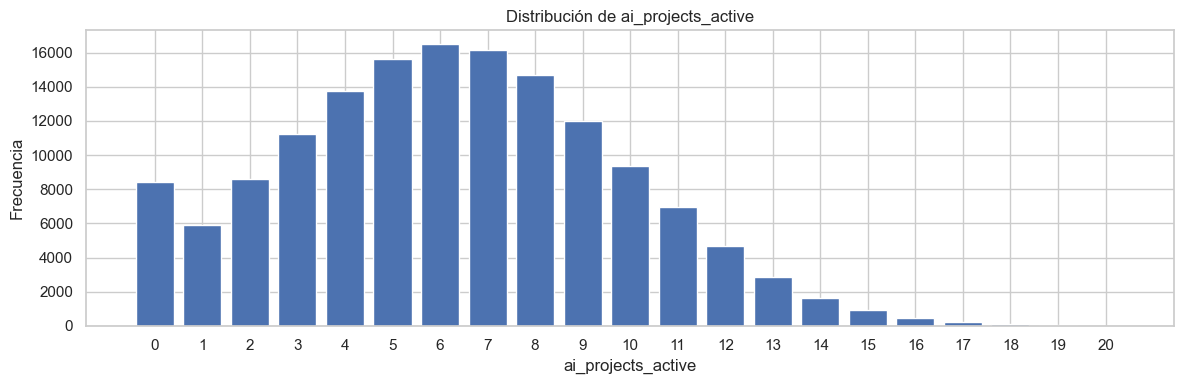

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

conteos = company_limpio['ai_projects_active'].value_counts().sort_index()
ax.bar(conteos.index, conteos.values, color='#4C72B0', edgecolor='white')

ax.set_title('Distribución de ai_projects_active')
ax.set_xlabel('ai_projects_active')
ax.set_ylabel('Frecuencia')
ax.set_xticks(range(0, 21))   # una marca por cada valor entero
plt.tight_layout()
plt.show()

La variable va de 0 a 20 proyectos, con un pico en torno a 6-7. Es una variable
discreta con bastante masa lejos del cero, lo que anticipa por qué el grupo NA no cae
tan abajo como en las otras: incluso las empresas sin adopción tienden a tener algunos
proyectos.

### ¿Cuántos registros NA caen por debajo del umbral en cada variable?

Bajamos del promedio al nivel de registro individual: de los ~5.200 registros NA,
contamos cuántos se ubican en la zona baja (por debajo del umbral) de cada variable.

In [19]:
na_mask = company_limpio['ai_adoption_stage'].isna()
vars3 = ['ai_maturity_score', 'ai_adoption_rate', 'years_using_ai', 'ai_projects_active']

for v in vars3:
    umbral = company_limpio[v].mean() - 1.5 * company_limpio[v].std()
    valores_na = company_limpio.loc[na_mask, v].dropna()
    arriba = (valores_na > umbral).sum()
    print(f'{v}: {arriba} registros NA por encima del umbral ({arriba/len(valores_na)*100:.1f}%)')

ai_maturity_score: 1590 registros NA por encima del umbral (30.6%)
ai_adoption_rate: 1 registros NA por encima del umbral (0.0%)
years_using_ai: 1 registros NA por encima del umbral (0.0%)
ai_projects_active: 2720 registros NA por encima del umbral (52.3%)


En `ai_adoption_rate` y `years_using_ai`, prácticamente el **100%** de los registros NA
cae en la zona baja (solo 1 excepción en cada una). En `ai_maturity_score`, el 30,6%. La
anomalía vuelve a ser `ai_projects_active`: el 52% queda por encima del umbral. Esto
confirma que el comportamiento raro se concentra en una sola variable, y que las otras
tres respaldan sólidamente la hipótesis.

### ¿Se relaciona `ai_projects_active` con las demás variables de adopción?

Para entender por qué esta variable no cae en la zona baja, analizamos si al menos se
*relaciona* con las otras variables de adopción. Dividimos cada variable en cuartiles
y observamos la media de proyectos activos en cada grupo. Si los proyectos crecen con
el cuartil, la variable sí captura adopción (no es ruido).

In [20]:
vars_x = ['ai_maturity_score', 'ai_adoption_rate', 'years_using_ai']
y = 'ai_projects_active'

def barras_por_cuartil(df, var, y, ax):
    """Media de 'y' según el cuartil de 'var', en barras."""
    d = df.dropna(subset=[var, y]).copy()
    d['grupo'] = pd.qcut(d[var], 4, labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'],
                         duplicates='drop')
    medias = d.groupby('grupo', observed=True)[y].mean()
    ax.bar(medias.index.astype(str), medias.values, color='#4C72B0', edgecolor='white')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    ax.set_title(f'{y} según cuartil de {var}')
    ax.set_xlabel(f'Cuartil de {var}')
    ax.set_ylabel(f'{y} (media)')


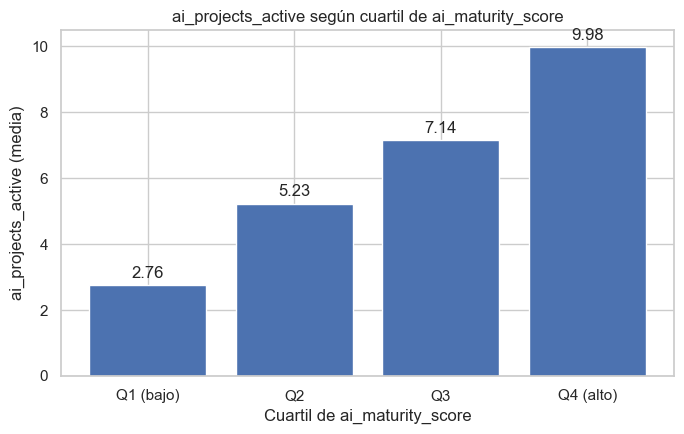

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
barras_por_cuartil(company_limpio, 'ai_maturity_score', y, ax)
plt.tight_layout()
plt.show()


La media de proyectos activos aumenta con claridad entre los cuartiles de madurez: pasa
de **2,76** en el cuartil inferior a **9,98** en el superior. Esto indica que
`ai_projects_active` sí captura la profundidad de la adopción.


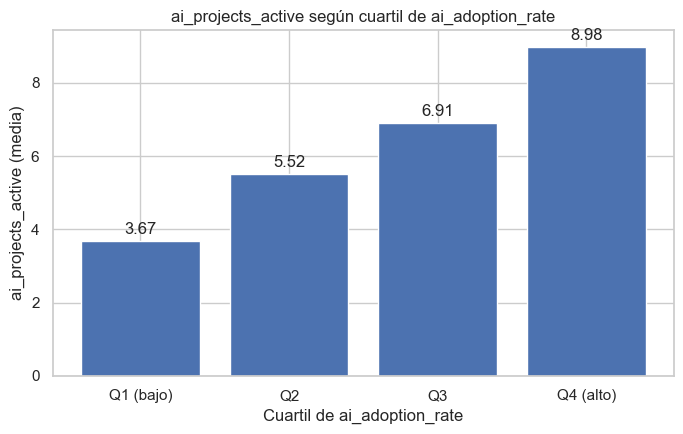

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
barras_por_cuartil(company_limpio, 'ai_adoption_rate', y, ax)
plt.tight_layout()
plt.show()


La tasa de adopción muestra el mismo patrón: la media de proyectos activos crece de
**3,67** en Q1 a **8,98** en Q4. Una adopción más extendida se asocia con más
proyectos en marcha.


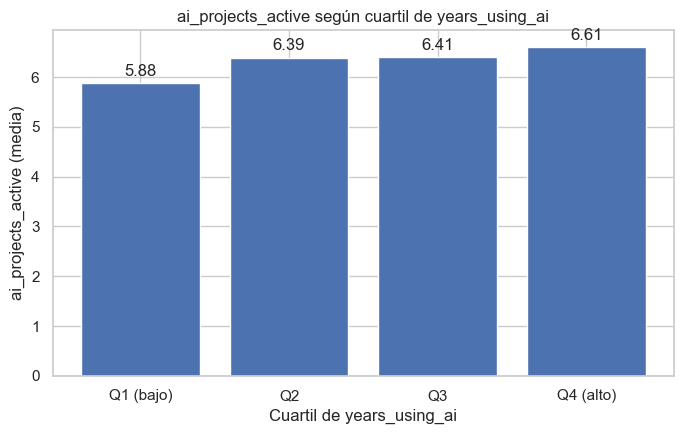

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
barras_por_cuartil(company_limpio, 'years_using_ai', y, ax)
plt.tight_layout()
plt.show()


Frente a los años de uso, la media permanece casi plana: **5,88** proyectos en Q1 y
**6,61** en Q4. En conjunto, los gráficos sugieren que los proyectos activos reflejan
mejor la *intensidad* actual de la adopción que su antigüedad. Incluso las empresas sin
adopción consolidada mantienen algunos proyectos exploratorios, lo que explica por qué
esta variable no cae por debajo del umbral absoluto usado anteriormente.


### Conclusión

El criterio del umbral respalda la hipótesis en tres de las cuatro variables de
control, donde el grupo NA se ubica sistemáticamente en la zona baja. En
`ai_projects_active` el umbral falla, pero no por contradecir la hipótesis: se debe a
que "sin adopción" no significa "cero actividad", y a que un umbral absoluto no es la
herramienta adecuada para una categoría entera (leído de forma relativa, `none` sigue
siendo el grupo con menos proyectos).

La evidencia definitiva, en cualquier caso, no proviene del umbral sino de la
comparación directa contra la categoría `none` en los datos crudos, donde el grupo NA
resultó **idéntico**. Concluimos que los NA de `ai_adoption_stage` no son datos
ausentes, sino la categoría `none` que la limpieza convirtió erróneamente en nulo, y
deben **recuperarse como tal**.




## 4) Análisis univariado

A continuación analizamos al menos cinco variables del archivo principal `company`:

1. `ai_adoption_rate` (numérica)
2. `ai_maturity_score` (numérica)
3. `productivity_change_percent` (numérica)
4. `industry` (categórica)
5. `company_size` (categórica)

Para las numéricas mostramos **histograma + boxplot** (forma, dispersión, asimetría y outliers).
Para categóricas mostramos **frecuencias relativas** (composición).

Además de los gráficos, cada celda imprime estadísticas básicas para respaldar la interpretación.

### Análisis de variables numéricas


In [24]:
num_vars = ['ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent']


#### Tasa de adopción de IA


count    147475.000000
mean         36.419684
std          14.541168
min           0.000000
25%          26.440000
50%          36.330000
75%          46.210000
max         100.000000
Name: ai_adoption_rate, dtype: float64


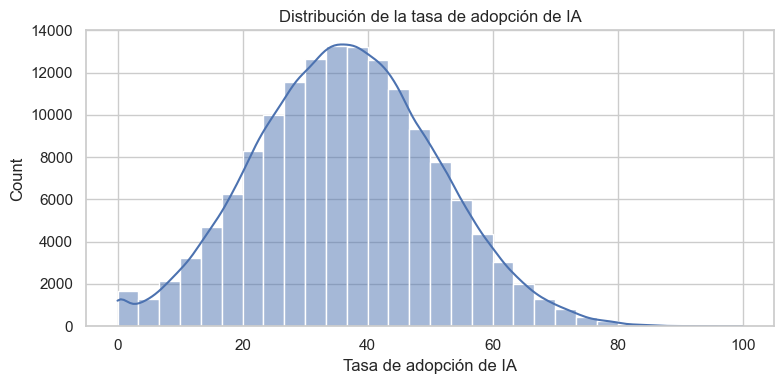

In [25]:
col = 'ai_adoption_rate'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
sns.histplot(company_limpio[col], bins=30, kde=True)
plt.title('Distribución de la tasa de adopción de IA')
plt.xlabel('Tasa de adopción de IA')
plt.tight_layout()
plt.show()


La distribución es aproximadamente simétrica y se concentra alrededor de **36**: la
media es **36,42** y la mediana **36,33**. La cercanía entre ambas medidas indica que
no existe una asimetría marcada en la mayor parte de los datos.


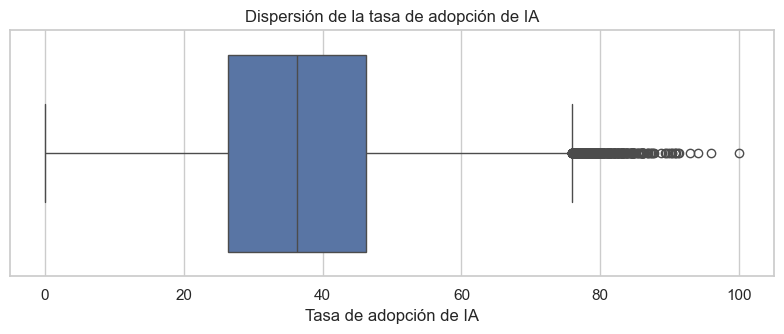

In [26]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['ai_adoption_rate'])
plt.title('Dispersión de la tasa de adopción de IA')
plt.xlabel('Tasa de adopción de IA')
plt.tight_layout()
plt.show()


El 50% central de los valores se encuentra entre **26,44** y **46,21**. La limpieza
convirtió en faltantes los registros fuera del rango lógico 0–100; los valores altos
que aún aparecen como extremos son observaciones válidas dentro de esa escala.


#### Madurez en IA


count    150025.000000
mean          0.344678
std           0.133817
min           0.000000
25%           0.250000
50%           0.341000
75%           0.435000
max           0.904000
Name: ai_maturity_score, dtype: float64


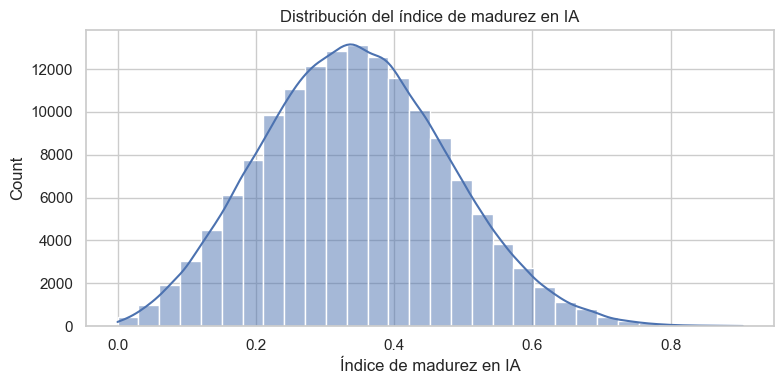

In [27]:
col = 'ai_maturity_score'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
sns.histplot(company_limpio[col], bins=30, kde=True)
plt.title('Distribución del índice de madurez en IA')
plt.xlabel('Índice de madurez en IA')
plt.tight_layout()
plt.show()


El índice se concentra alrededor de **0,34** y presenta una forma aproximadamente
simétrica. La media (**0,345**) y la mediana (**0,341**) son muy similares.


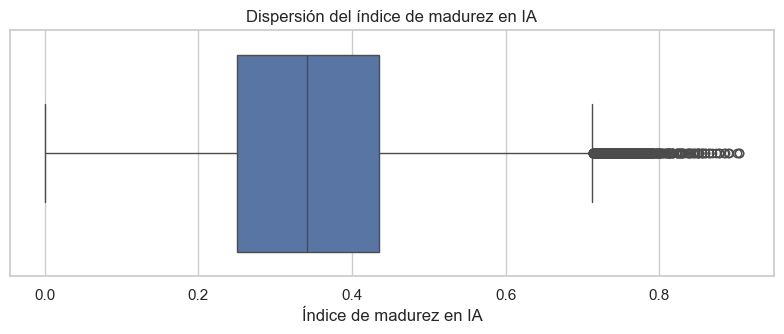

In [28]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['ai_maturity_score'])
plt.title('Dispersión del índice de madurez en IA')
plt.xlabel('Índice de madurez en IA')
plt.tight_layout()
plt.show()


La mitad central de los casos se ubica entre **0,250** y **0,435**, mientras que el
máximo alcanza **0,904**. Los pocos valores del extremo superior representan empresas
con una madurez considerablemente mayor que la mayoría.


#### Cambio porcentual en la productividad


count    150025.000000
mean          9.310881
std           6.368602
min         -57.053637
25%           5.060000
50%           9.060000
75%          13.130000
max         119.200258
Name: productivity_change_percent, dtype: float64


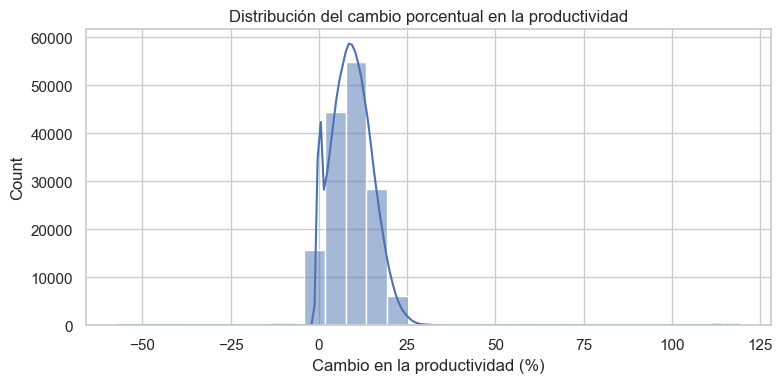

In [29]:
col = 'productivity_change_percent'
print(company_limpio[col].describe())

plt.figure(figsize=(8, 4))
sns.histplot(company_limpio[col], bins=30, kde=True)
plt.title('Distribución del cambio porcentual en la productividad')
plt.xlabel('Cambio en la productividad (%)')
plt.tight_layout()
plt.show()


La mayor parte de las observaciones se concentra cerca de un aumento del **9%**: la
media es **9,31%** y la mediana **9,06%**. También existen cambios negativos y mejoras
muy superiores al nivel habitual.


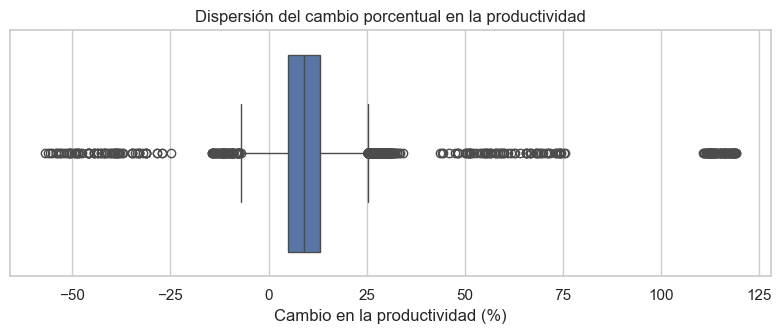

In [30]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=company_limpio['productivity_change_percent'])
plt.title('Dispersión del cambio porcentual en la productividad')
plt.xlabel('Cambio en la productividad (%)')
plt.tight_layout()
plt.show()


El 50% central está entre **5,06%** y **13,13%**, pero el rango completo va de
**−57,05%** a **119,20%**. El boxplot hace visibles observaciones extremas en ambas
direcciones, compatibles con caídas importantes o con aumentos superiores al 100%.

Aunque `ai_adoption_rate` y `ai_maturity_score` tienen escalas parecidas en términos
relativos, sus nombres no bastan para concluir que una sea una transformación de la
otra. Esa posible redundancia debe evaluarse mediante su relación estadística.


### Análisis de variables categóricas

La siguiente celda cubre dos variables categóricas con mayor impacto interpretativo:

- `industry`: permite identificar sectores más representados y contextualizar comparaciones.
- `company_size`: muestra composición por tamaño empresarial, importante porque puede sesgar niveles de inversión/adopción.

Usamos frecuencias normalizadas (`value_counts(normalize=True)`) para que la lectura sea porcentual y comparable.

In [31]:
def graficar_frecuencia_relativa(df, col):
    """Grafica la frecuencia relativa de las diez categorías más frecuentes."""
    frecuencias = df[col].value_counts(dropna=True, normalize=True).head(10)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=frecuencias.index, y=frecuencias.values)
    plt.title(f'Frecuencia relativa de {col}')
    plt.gca().yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f'{y:.0%}')
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, frecuencias.max() + 0.05)

    for i, value in enumerate(frecuencias.values):
        plt.text(i, value + 0.01, f'{value:.2%}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


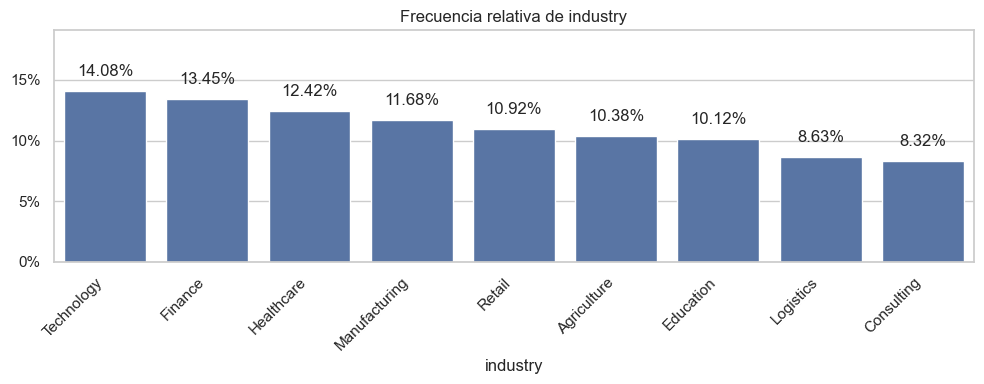

In [32]:
graficar_frecuencia_relativa(company_limpio, 'industry')


`Technology` es la industria con mayor representación, con **14,08%** de los
registros. La composición sectorial no es uniforme, por lo que las comparaciones entre
industrias deben considerar sus distintos tamaños muestrales.


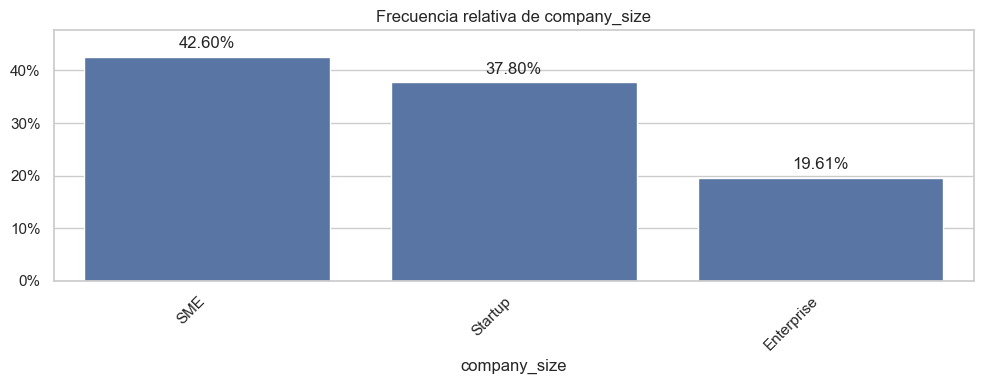

In [33]:
graficar_frecuencia_relativa(company_limpio, 'company_size')


Las empresas `SME` constituyen la categoría de tamaño más frecuente, con **42,6%** de
los registros. Esta mayor presencia de empresas pequeñas y medianas puede influir en
los resultados agregados de inversión y adopción, por lo que conviene controlar el
tamaño empresarial en análisis posteriores.


## 5) Análisis bivariado y comparaciones
Aquí exploramos tres relaciones alineadas con la consigna:

1. **Adopción de IA por industria**
   - Pregunta: qué sectores muestran mayor/menor tasa de adopción?
   - Gráfico: boxplot por industria para observar nivel típico y variabilidad.

2. **Inversión en IA vs cambio de productividad**
   - Pregunta: mayor inversión por empleado se asocia con mayor productividad?
   - Gráfico: dispersión con tendencia lineal (`regplot`).

3. **Diferencias entre regiones y vínculo país-madurez digital**
   - Preguntas: hay brechas de adopción por región? la madurez digital del país se relaciona con adopción promedio?
   - Gráficos: barplot por región + dispersión entre `digital_maturity_index` y adopción promedio por país.

### Adopción de IA por industria

#### Adopción de IA por industria en el último trimestre disponible


C:\Users\erics\AppData\Local\Temp\ipykernel_23888\390993029.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  industry_df['period'] = pd.PeriodIndex(


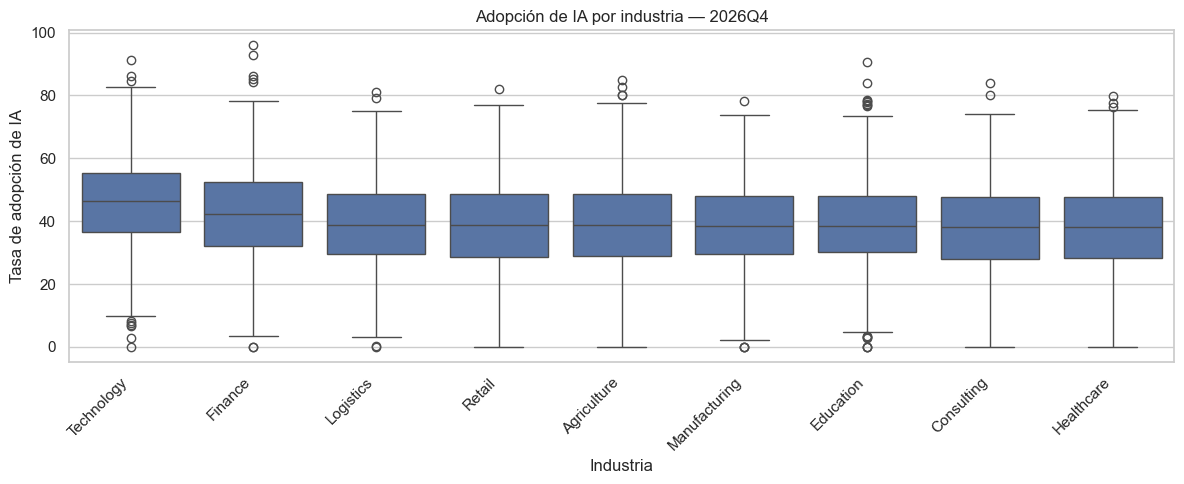

industry
Technology       45.92
Finance          42.38
Education        39.10
Agriculture      38.95
Logistics        38.77
Manufacturing    38.68
Retail           38.65
Healthcare       38.09
Consulting       37.73
Name: ai_adoption_rate, dtype: float64

In [34]:
industry_df = company_limpio.dropna(
    subset=['company_id', 'survey_year', 'quarter',
            'industry', 'ai_adoption_rate']
).copy()

industry_df['period'] = pd.PeriodIndex(
    year=industry_df['survey_year'].astype(int),
    quarter=industry_df['quarter'].str.extract(r'(\d)')[0].astype(int),
    freq='Q'
)

latest_period = industry_df['period'].max()

industry_latest = industry_df[
    industry_df['period'].eq(latest_period)
].copy()

industry_order = (
    industry_latest
    .groupby('industry')['ai_adoption_rate']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=industry_latest,
    x='industry',
    y='ai_adoption_rate',
    order=industry_order
)

plt.title(f'Adopción de IA por industria — {latest_period}')
plt.xlabel('Industria')
plt.ylabel('Tasa de adopción de IA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

industry_latest.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)

El nivel de adopción de IA por industria del último trimestre común muestra un claro liderazgo del sector tecnológico, algo que podría reflejar una mayor inversión en innovación y adopción de tecnologías emergentes en este sector, lo cual es esperable.

Nos preguntamos si la evolución de la adopción de IA a lo largo del tiempo es consistente entre industrias, o si algunas industrias muestran un crecimiento más rápido que otras. Para esto, podemos analizar la tendencia temporal de la adopción de IA por industria y observar si hay diferencias significativas en las tasas de crecimiento.

#### Evolución de la adopción mediana de la IA por industria a lo largo del tiempo


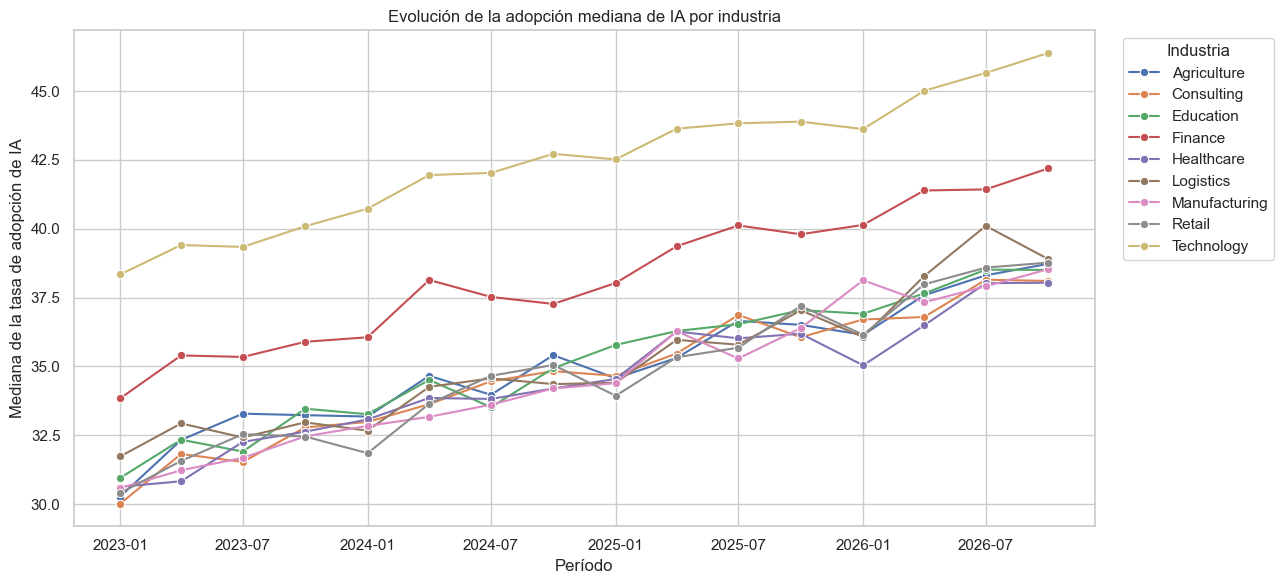

In [35]:
industry_evolution = (
    industry_df
    .groupby(['period', 'industry'])['ai_adoption_rate']
    .agg(
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        companies='count'
    )
    .reset_index()
)

industry_evolution['date'] = (
    industry_evolution['period'].dt.to_timestamp()
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=industry_evolution,
    x='date',
    y='median',
    hue='industry',
    marker='o'
)

plt.title('Evolución de la adopción mediana de IA por industria')
plt.xlabel('Período')
plt.ylabel('Mediana de la tasa de adopción de IA')
plt.legend(title='Industria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Todas las industrias muestran un ritmo de crecimiento similar en la adopción de IA a lo largo del tiempo. Sin embargo, los sectores tecnológico y financiero llevan siempre una ventaja en la adopción de IA, lo que podría reflejar una mayor inversión en innovación y adopción de tecnologías emergentes en estos sectores.

Es importante destacar que, aunque los sectores tecnológico y financiero lideran la adopción de IA, todas las industrias muestran un patrón de crecimiento consistente. Esto sugiere que la adopción de IA está aumentando de manera generalizada en todos los sectores, aunque con diferentes niveles iniciales de adopción.

### Inversión en IA por empleado vs cambio de productividad

#### Relacion de inversion por empleado en ia y cambio en la productividad en el ultimo cuatrimestre de 2026

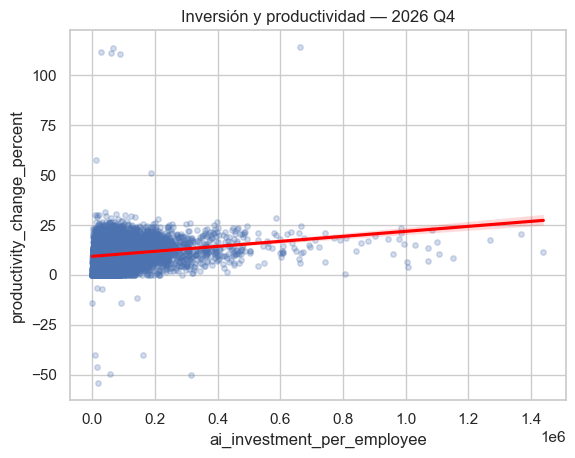

,ai_investment_per_employee,productivity_change_percent
ai_investment_per_employee,1.0000,0.1903
productivity_change_percent,0.1903,1.0000


In [37]:
panel = company_limpio.dropna(
    subset=[
        'company_id',
        'survey_year',
        'quarter',
        'ai_investment_per_employee',
        'productivity_change_percent'
    ]
).copy()

panel['quarter_num'] = (
    panel['quarter']
    .str.extract(r'(\d)')[0]
    .astype(int)
)

latest_year = panel['survey_year'].max()
latest_quarter = panel.loc[
    panel['survey_year'].eq(latest_year),
    'quarter_num'
].max()

latest = panel[
    panel['survey_year'].eq(latest_year)
    & panel['quarter_num'].eq(latest_quarter)
    & panel['ai_investment_per_employee'].ge(0)
]

sns.regplot(
    data=latest,
    x='ai_investment_per_employee',
    y='productivity_change_percent',
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'red'}
)

plt.title(f'Inversión y productividad — {int(latest_year)} Q{latest_quarter}')
plt.show()

latest[
    ['ai_investment_per_employee', 'productivity_change_percent']
].corr()

De acuerdo con los datos disponibles del último trimestre del 2025, la correlación entre las variables es muy baja ($r=0.19$) y el gráfico de dispersión da cuenta de que no hay una relación muy clara entre las variables: incluso niveles bajos de inversión están asociados a cambios grandes en la productividad, mientras que niveles altos de inversión no parecen motorizar grandes cambios. 

A continuación, analizamos el promedio de inversión por empleado por compañía a lo largo de todo el período, y lo comparamos con el cambio de productividad promedio por compañía. Esto nos permite observar si existe alguna relación a nivel agregado, en lugar de a nivel individual. 

,avg_ai_investment,avg_productivity_change
avg_ai_investment,1.000000,0.239066
avg_productivity_change,0.239066,1.000000


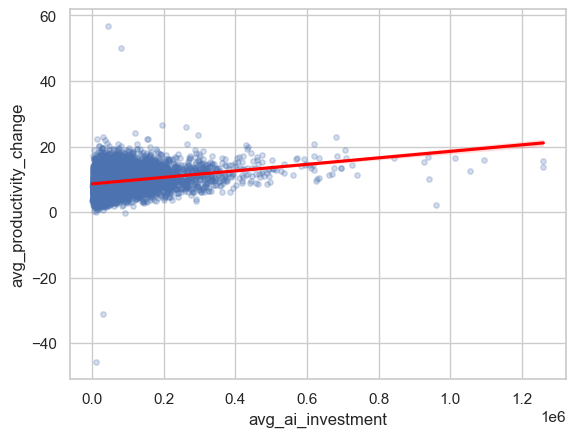

In [38]:
company_level = (
    panel[panel['ai_investment_per_employee'].ge(0)]
    .groupby('company_id', as_index=False)
    .agg(
        avg_ai_investment=('ai_investment_per_employee', 'mean'),
        avg_productivity_change=('productivity_change_percent', 'mean')
    )
)

sns.regplot(
    data=company_level,
    x='avg_ai_investment',
    y='avg_productivity_change',
    scatter_kws={'alpha': 0.25, 's': 15},
    line_kws={'color': 'red'}
)

company_level[
    ['avg_ai_investment', 'avg_productivity_change']
].corr()

Al agregar los datos temporales por compañía, la correlación entre las variables aumenta ligeramente ($r=0.2383$), como se observa en el gráfico de dispersión y en la matriz de correlación. Esto sugiere una relación más clara entre inversión y productividad cuando se considera la inversión promedio por empleado a lo largo del tiempo, en lugar de observar solo un trimestre aislado.

Sin embargo, la relación sigue siendo débil y no podemos concluir que exista una relación causal entre inversión en IA y cambio de productividad. Es posible que otros factores estén influyendo en la productividad, como la calidad de la implementación de la IA, la capacitación de los empleados o el contexto económico general.

### Diferencias entre regiones y vínculo país-madurez digital

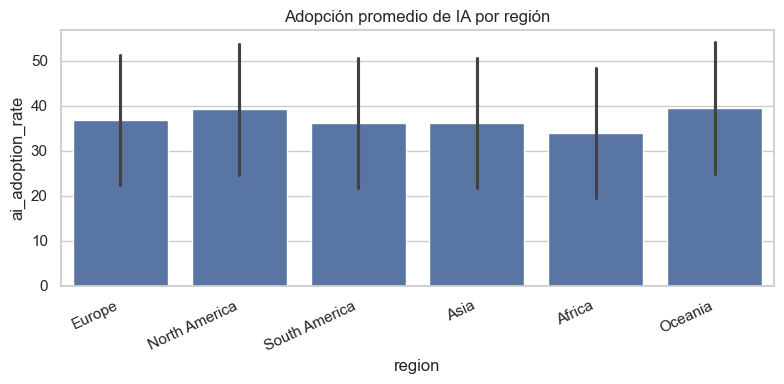

In [39]:
plt.figure(figsize=(8, 4))
# Add error bars representing the standard deviation of ai_adoption_rate within each region
sns.barplot(data=company_limpio, x='region', y='ai_adoption_rate', errorbar='sd')
plt.title('Adopción promedio de IA por región')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

Los continentes con mayor tasa de adopción de IA son Oceanía y América del Norte, mientras que Asia y África muestran las tasas de adopción más bajas. Esto es algo que podría esperarse, dado que los países de Oceanía y América del Norte suelen tener economías más desarrolladas y una mayor inversión en tecnología e innovación. Por otro lado, Asia y África presentan desafíos estructurales y económicos que podrían limitar la adopción de IA. Es importante reconocer que Asia es una región muy heterogénea, con países como Japón y Corea del Sur que tienen tasas de adopción de IA muy altas, mientras que otros países asiáticos tienen tasas mucho más bajas. Esto sugiere que la adopción de IA no está determinada únicamente por la región geográfica, sino también por factores económicos, políticos y culturales específicos de cada país. La dispersión de los datos por región muestra que, aunque hay diferencias entre continentes, también existen variaciones significativas dentro de cada región.

In [40]:
import plotly.express as px

country_adoption = (
    company
    .groupby('country', as_index=False)['ai_adoption_rate']
    .mean()
)

country_merged = (
    country_adoption
    .merge(
        country[['country', 'digital_maturity_index', 'region']],
        on='country',
        how='left'
    )
)

correlacion_pais = country_merged[
    ['digital_maturity_index', 'ai_adoption_rate']
].corr().iloc[0, 1]

fig = px.scatter(
    country_merged,
    x='digital_maturity_index',
    y='ai_adoption_rate',
    color='region',
    hover_name='country',
    hover_data={
        'digital_maturity_index': ':.3f',
        'ai_adoption_rate': ':.2f',
        'region': True
    },
    title=(
        'Madurez digital del país vs adopción promedio de IA por región '
        f'(r = {correlacion_pais:.3f})'
    ),
    labels={
        'digital_maturity_index': 'Índice de madurez digital',
        'ai_adoption_rate': 'Tasa promedio de adopción de IA'
    },
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()


El gráfico de dispersión entre el índice de madurez digital y la adopción promedio de IA por país muestra una relación positiva, aunque no perfecta ($r=0.521$). Esto sugiere que los países con mayor madurez digital tienden a tener una mayor adopción de IA, lo que podría reflejar una mayor capacidad para implementar y aprovechar tecnologías avanzadas. 

Algo importante a destacar es que, aunque existe una relación positiva entre madurez digital y adopción de IA, hay excepciones notables. Algunos países con alta madurez digital no tienen una adopción de IA tan alta como se esperaría, como China, mientras que otros países con menor madurez digital muestran una adopción de IA relativamente alta, como Colombia, Vietnam o Indonesia. Esto indica que la adopción de IA no depende únicamente de la madurez digital, sino que también está influenciada por otros factores, como políticas gubernamentales, inversión en investigación y desarrollo, y la cultura empresarial.

Otro hallazgo interesante es que, en general, las regiones son relativamente homogéneas, pero Asia es la excepción: algunos países asiáticos tienen una adopción de IA muy alta, mientras que otros tienen una adopción muy baja. Esto sugiere que la región asiática es muy heterogénea en términos de adopción de IA, y que no se puede generalizar sobre la región en su conjunto.

## 6) Análisis de probabilidad

Hasta aquí describimos los datos con promedios y correlaciones. En esta sección
cambiamos de lente y miramos el fenómeno desde la **probabilidad**, para responder dos
preguntas:

1. ¿Las ventajas de la IA (adopción, madurez, productividad) se **concentran** en las
   mismas empresas, o están repartidas?
2. ¿Tener valores altos en las variables de adopción **aumenta la probabilidad** de un
   salto grande de productividad?

### 6.1 ¿Las ventajas se concentran en las mismas empresas?

Calculamos la probabilidad de que una empresa esté simultáneamente en el cuarto
superior (por encima del cuartil Q3) de las tres variables clave. La comparamos contra
un punto de referencia: si las tres fueran independientes, esa probabilidad sería
0,25 × 0,25 × 0,25 ≈ 1,6%. Si el valor real es mucho mayor, significa que ser líder en
una dimensión coincide con serlo en las otras.

El resultado —**12,47%**— es unas **8 veces** mayor al 1,6% esperable por azar. Esto
indica que estar en el cuarto superior de adopción, madurez y productividad **no son
hechos separados: coinciden en las mismas empresas**. Existe un perfil coherente de
"empresa ganadora".

In [41]:
# Uso solo filas con las tres variables presentes (sin NaN)
df = company_limpio.dropna(subset=num_vars)

# Q3 (percentil 75) de cada variable
q3 = df[num_vars].quantile(0.75)

# Máscara: ¿está por encima del Q3 en las TRES a la vez?
arriba_todas = (
    (df['ai_adoption_rate'] > q3['ai_adoption_rate']) &
    (df['ai_maturity_score'] > q3['ai_maturity_score']) &
    (df['productivity_change_percent'] > q3['productivity_change_percent'])
)

# La probabilidad es la proporción de filas que cumplen
probabilidad = arriba_todas.mean()
print(f'P(arriba de Q3 en las tres): {probabilidad*100:.2f}%')

P(arriba de Q3 en las tres): 12.47%


Esto nos llevó a la segunda pregunta: entre las variables de adopción, ¿cuáles se
asocian realmente a un gran incremento de productividad?

### 6.2 ¿Qué variables de IA elevan la probabilidad de un salto de productividad?

Dividimos cada variable de adopción en cuartiles (de Q1 = bajo a Q4 = alto) y, para
cada grupo, calculamos la probabilidad de una mejora de productividad "grande"
(> 20%). Elegimos el umbral de 20% porque uno más exigente (50%) era demasiado raro
—solo lo alcanza el 0,1% de las empresas— y no dejaba ver ningún patrón.

**Qué observar en cada gráfico:** si las barras crecen de Q1 a Q4, significa que a
mayor nivel de la variable, mayor probabilidad de un salto de productividad. El
contraste entre variables permite comprobar que no todas se comportan igual.


In [42]:
UMBRAL = 20  # % de mejora de productividad que consideramos "grande"

def prob_por_cuartil(df, variable, umbral=UMBRAL):
    """P(mejora de productividad > umbral) para cada cuartil de 'variable'."""
    d = df.dropna(subset=[variable, 'productivity_change_percent']).copy()
    # divido la variable en 4 grupos de igual tamaño (cuartiles)
    d['grupo'] = pd.qcut(d[variable], 4, labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])
    # dentro de cada grupo, qué fracción supera el umbral
    prob = d.groupby('grupo', observed=True)['productivity_change_percent'].apply(
        lambda s: (s > umbral).mean() * 100
    )
    return prob.round(2)

vars_ia = ['ai_adoption_rate', 'ai_maturity_score', 'years_using_ai']

tabla = pd.DataFrame({v: prob_por_cuartil(company_limpio, v) for v in vars_ia})
tabla.index.name = 'Cuartil'
print(f'P(mejora de productividad > {UMBRAL}%) por cuartil de cada variable de IA:')

tabla

P(mejora de productividad > 20%) por cuartil de cada variable de IA:


,ai_adoption_rate,ai_maturity_score,years_using_ai
Cuartil,,,
Q1 (bajo),0.13,0.11,3.10
Q2,0.36,0.21,3.54
Q3,1.61,1.12,3.58
Q4 (alto),12.16,12.85,4.41


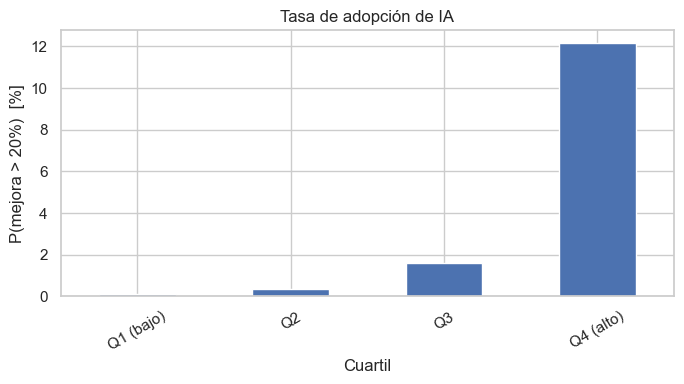

In [43]:
ax = prob_por_cuartil(company_limpio, 'ai_adoption_rate').plot(
    kind='bar', figsize=(7, 4), color='#4C72B0'
)
ax.set_title('Tasa de adopción de IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%)  [%]')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


La probabilidad aumenta de **0,13%** en el cuartil inferior a **12,16%** en el
superior, unas **94 veces** más. Una tasa de adopción alta se asocia fuertemente con
una mayor probabilidad de superar el 20% de mejora en productividad.


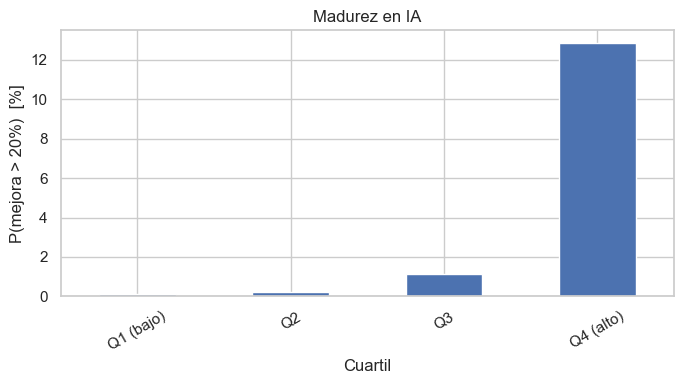

In [44]:
ax = prob_por_cuartil(company_limpio, 'ai_maturity_score').plot(
    kind='bar', figsize=(7, 4), color='#4C72B0'
)
ax.set_title('Madurez en IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%)  [%]')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


El salto es todavía más marcado para la madurez: de **0,11%** en Q1 a **12,85%** en
Q4, alrededor de **117 veces** más. La profundidad de la adopción aparece asociada
con los mejores resultados de productividad.


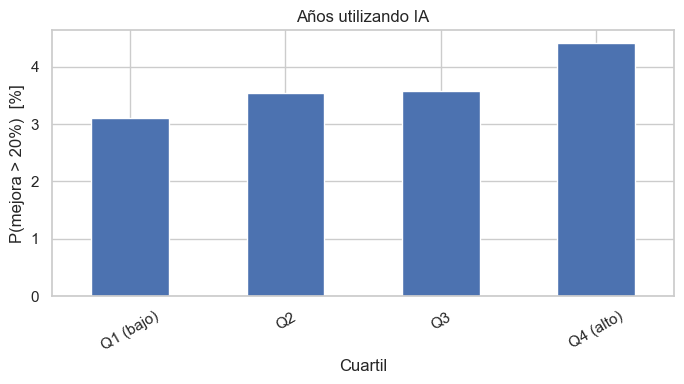

In [45]:
ax = prob_por_cuartil(company_limpio, 'years_using_ai').plot(
    kind='bar', figsize=(7, 4), color='#4C72B0'
)
ax.set_title('Años utilizando IA')
ax.set_xlabel('Cuartil')
ax.set_ylabel(f'P(mejora > {UMBRAL}%)  [%]')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


La antigüedad de uso presenta una variación mucho menor: la probabilidad pasa de
**3,10%** a **4,41%** entre Q1 y Q4. El tiempo usando IA, por sí solo, diferencia poco
a las empresas que logran grandes mejoras de productividad.


### Conclusión del análisis de probabilidad

El análisis de probabilidad revela dos cosas. Primero, que **las ventajas de la IA se
concentran**: las empresas líderes lo son en varias dimensiones a la vez, mucho más de
lo que el azar explicaría. Segundo, y más importante, que **lo que distingue a las
empresas con mejores resultados no es cuánto tiempo hace que usan IA, sino cuán intensa
y profunda es esa adopción**: la madurez y la tasa de adopción multiplican por ~100 la
probabilidad de un gran salto de productividad, mientras que la antigüedad casi no
influye.

La variable `ai_adoption_stage` —la que recuperamos de los valores faltantes— confirma
esta lectura: la probabilidad de una mejora grande pasa de 0,2% en empresas en etapa
`pilot` a **48,6%** en las que están en `full`.

*Nota: este es un análisis exploratorio sobre datos observacionales. Las relaciones
descritas son asociaciones, no relaciones causales, y constituyen hipótesis a
contrastar en los próximos prácticos.*

## 7) Conclusiones e hipótesis de investigación

Hemos limpiado la base de datos y hemos explorado algunas variables clave, tanto de manera univariada como bivariada. A partir de este análisis, podemos formular algunas hipótesis de investigación para los próximos prácticos:

1. **Hipótesis sobre la relación entre inversión en IA y productividad**: 
   - **Formulación:** ¿La inversión en IA por empleado se asocia con un cambio positivo en la productividad de la empresa, controlando por industria y tamaño de la empresa?
   - **Justificación:** Aunque la correlación observada es débil, podríamos investigar si existen condiciones específicas (como tamaño de empresa, industria o región) bajo las cuales la inversión en IA tenga un impacto más significativo en la productividad. Aquí se podrían considerar variables de control como el grado de madurez de las iniciativas de IA (`ai_maturity_score`), la cantidad de horas de capacitación en IA (`ai_training_hours`), el grado de madurez digital de la región o del país (`digital_maturity_index`), la capacidad de innovación de la empresa (`innovation_score`) o el nivel de automatización de tareas (`task_automation_rate`).

2. **Hipótesis sobre la adopción de IA por industria**: 
   - **Formulación:** ¿Existen diferencias significativas en la adopción de IA entre industrias, y cuáles son los factores que facilitan o limitan la adopción en cada sector?
   - **Justificación:** Dado que el sector tecnológico lidera en adopción de IA, podríamos explorar cuáles son los factores que facilitan la adopción en este sector, como la capacidad de innovación (`innovation_score`), la inversión por empleado para capacitación en IA dentro de este sector (`ai_training_hours_per_employee` y `ai_investment_per_employee`). Además, podríamos investigar si  existen barreras específicas que limitan la adopción de IA en otros sectores, como una menor inversión en innovación, una mayor cantidad de proyectos fallidos (`ai_failure_rate`) o una menor cantidad de años utilizando IA (`years_using_ai`). También podríamos analizar si la adopción de IA en industrias específicas está relacionada con la madurez digital de los países en los que operan, considerando variables como el `digital_maturity_index` y el `regulatory_compliance_score`.

3. **Hipótesis sobre la adopción de IA y la destrucción o creación de empleo**:
   - **Formulación:** ¿La adopción de IA está asociada con la creación o destrucción de empleo en las empresas, y cómo varía esta relación según la industria y el tamaño de la empresa?
   - **Justificación:** Dado que la adopción de IA puede tener efectos tanto positivos como negativos en el empleo, podríamos investigar si las empresas que adoptan IA tienden a crear más empleos (por ejemplo, a través de la creación de nuevos roles relacionados con IA) o si tienden a desplazar empleos existentes. Podríamos analizar la relación entre la adopción de IA y la cantidad de empleos desplazados (`jobs_displaced`) y creados (`jobs_created`), considerando variables de control como el tamaño de la empresa (`company_size`), la industria (`industry`), la inversión en capacitación en IA (`ai_training_hours`), el nivel de automatización de tareas (`task_automation_rate`) y la satisfacción de los empleados (`employee_satisfaction_score`).